# Home Credit Default Risk
## Sprint 1 — Definição do Problema e Análise Exploratória de Dados

**Dataset:** `application_train.csv` (~307k linhas, 122 colunas)  
**Target:** `TARGET` — 0 = pagou normalmente, 1 = dificuldade de pagamento nas parcelas iniciais  
**Tipo de tarefa:** Classificação binária  

---

## Seção 1 — Apresentação do Projeto

### Pergunta de negócio

No momento da solicitação de crédito, quais clientes têm risco de inadimplência alto o suficiente para justificar negação automática ou revisão manual, considerando que rejeitar um bom pagador tem custo de oportunidade e aprovar um mau pagador tem custo de perda financeira direta?

### Por que accuracy não é a métrica certa

A base tem ~8% de inadimplentes. Um modelo trivial que prevê 0 para todos os casos entrega 92% de accuracy sem nenhum valor preditivo. O objetivo é construir um modelo cujas métricas reflitam o tradeoff assimétrico entre falso negativo (aprovar inadimplente = perda financeira direta) e falso positivo (negar bom pagador = custo de oportunidade).

### Escopo desta sprint

Entender a estrutura dos dados disponíveis no momento da decisão de crédito — sem tratamento de missings, encoding, feature engineering ou treinamento de modelo. Isso fica para sprints posteriores.

## Seção 2 — Carregamento e Visão Geral

Tópicos a cobrir:

- Carregamento de `data/raw/application_train.csv`
- Shape do dataframe
- Tipos de colunas (numéricas vs categóricas)
- Percentual de valores nulos por feature — heatmap e ranking
- Primeiras linhas e estatísticas descritivas básicas (`describe()`)

1. CARREGAMENTO E SHAPE

Dataset: application_train.csv
Shape: 307,511 linhas × 122 colunas

2. TIPOS DE COLUNAS

Numéricas: 106
Categóricas: 16

Detalhes dos tipos:
float64    65
int64      41
object     16
Name: count, dtype: int64

3. PERCENTUAL DE VALORES NULOS POR FEATURE

Total de features com missing: 67

Ranking das features com maior % de nulos:
                     Feature  Missing_Count  Missing_Percent
             COMMONAREA_MEDI         214865            69.87
              COMMONAREA_AVG         214865            69.87
             COMMONAREA_MODE         214865            69.87
    NONLIVINGAPARTMENTS_MODE         213514            69.43
     NONLIVINGAPARTMENTS_AVG         213514            69.43
    NONLIVINGAPARTMENTS_MEDI         213514            69.43
          FONDKAPREMONT_MODE         210295            68.39
       LIVINGAPARTMENTS_MODE         210199            68.35
        LIVINGAPARTMENTS_AVG         210199            68.35
       LIVINGAPARTMENTS_MEDI     

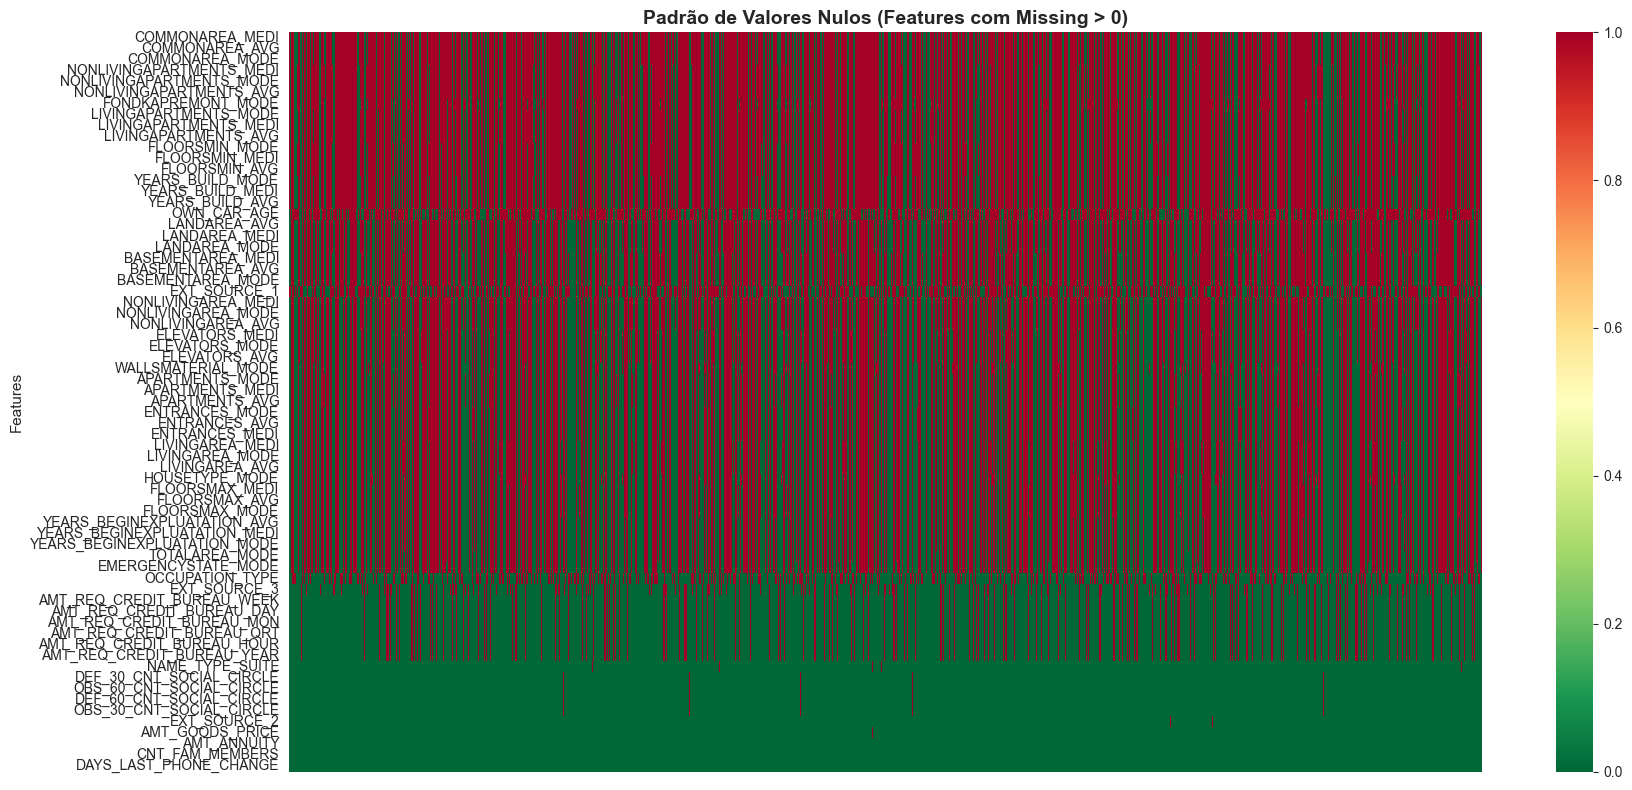


4. PRIMEIRAS 5 LINHAS
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...        

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. CARREGAMENTO DO DATASET
df = pd.read_csv('../data/raw/application_train.csv')

print("=" * 80)
print("1. CARREGAMENTO E SHAPE")
print("=" * 80)
print(f"\nDataset: application_train.csv")
print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# 2. TIPOS DE COLUNAS
print("\n" + "=" * 80)
print("2. TIPOS DE COLUNAS")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNuméricas: {len(numeric_cols)}")
print(f"Categóricas: {len(categorical_cols)}")
print(f"\nDetalhes dos tipos:")
print(df.dtypes.value_counts())

# 3. VALORES NULOS - RANKING
print("\n" + "=" * 80)
print("3. PERCENTUAL DE VALORES NULOS POR FEATURE")
print("=" * 80)

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False).reset_index(drop=True)

print(f"\nTotal de features com missing: {(missing_data['Missing_Count'] > 0).sum()}")
print("\nRanking das features com maior % de nulos:")
print(missing_data[missing_data['Missing_Count'] > 0].to_string(index=False))

# 4. HEATMAP DE VALORES NULOS
print("\n" + "=" * 80)
print("VISUALIZAÇÃO: Heatmap de Valores Nulos")
print("=" * 80)

fig, ax = plt.subplots(figsize=(18, 8))
missing_mask = df.isnull().T
missing_mask = missing_mask[missing_mask.sum(axis=1) > 0]
missing_mask = missing_mask.loc[missing_mask.sum(axis=1).sort_values(ascending=False).index]
sns.heatmap(missing_mask, cbar=True, yticklabels=True, xticklabels=False, ax=ax, cmap='RdYlGn_r')
ax.set_title('Padrão de Valores Nulos (Features com Missing > 0)', fontsize=14, fontweight='bold')
ax.set_ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

# 5. PRIMEIRAS LINHAS
print("\n" + "=" * 80)
print("4. PRIMEIRAS 5 LINHAS")
print("=" * 80)
print(df.head())

# 6. ESTATÍSTICAS DESCRITIVAS
print("\n" + "=" * 80)
print("5. ESTATÍSTICAS DESCRITIVAS BÁSICAS")
print("=" * 80)
print(df.describe().T)

## Seção 3 — Análise Univariada

Tópicos a cobrir:

- Distribuição do target (`TARGET`) — proporção 0/1, implicações para modelagem
- Distribuição das principais features numéricas (histogramas, detecção de outliers)
- Distribuição das features categóricas (frequência de categorias)
- Identificação de colunas com baixa variância ou alta concentração em uma categoria

## Seção 4 — Análise Bivariada e Multivariada

Tópicos a cobrir:

- Correlação entre features numéricas (heatmap)
- Relação entre features e TARGET — boxplots, violin plots, proporção de inadimplência por categoria
- Features com maior poder discriminativo aparente
- Multicolinearidade — pares de features altamente correlacionadas

In [ ]:
## codigo

## Seção 5 — Achados e Hipóteses

Tópicos a cobrir:

- Síntese dos principais padrões observados nas seções anteriores
- Hipóteses sobre features relevantes para o modelo
- Desafios identificados para pré-processamento (Sprint 2): missings críticos, outliers, encoding necessário
- Questões em aberto e decisões a tomar nas próximas sprints

In [ ]:
## codigo